# Unit14_Example_06 | 製程能力分析與統計製程管制指標

本 Notebook 以化工廠黏度製程為例，示範如何使用 `scipy.stats` 進行製程能力分析（Process Capability Analysis）與統計製程管制指標（SPC）計算。

## 目標
- 生成含製程偏移之模擬黏度數據（前段穩定，後段均值偏移）
- 計算製程能力指標 $C_p$ （精密度）與 $C_{pk}$ （準確度含對中）
- 使用 `scipy.stats.norm.cdf()` 計算良率與不良率（ppm）
- 使用 `scipy.stats.norm.interval(0.9973)` 計算 ±3σ 管制界限（UCL / CL / LCL）
- 繪製個別觀測值管制圖，標示失控點與製程偏移位置
- 以 `scipy.stats.ttest_1samp()` 檢定製程均值是否顯著偏離目標值
- 繪製製程能力圖（直方圖 ＋ 常態 PDF ＋ 規格線）


---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit14_Example_06'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit14'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit14
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_06
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_06\figs


---
### 1. 載入套件

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")


✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 模擬黏度數據生成（含製程偏移）

**製程背景：**
- 黏度規格：目標值 100 cP，規格範圍 100 ± 10 cP（LSL = 90，USL = 110 cP）
- 第 1–70 批：穩定製程，均值 100 cP，σ = 3 cP
- 第 71–100 批：均值偏移至 104 cP（模擬原料批次更換），σ = 3 cP

In [3]:
# ---- 製程規格設定 ----
TARGET   = 100.0   # 目標值 (cP)
LSL      = 90.0    # 規格下限 Lower Spec Limit (cP)
USL      = 110.0   # 規格上限 Upper Spec Limit (cP)
TRUE_STD = 3.0     # 製程標準差 (cP)
N_STABLE = 70      # 穩定批次數
N_SHIFT  = 30      # 偏移批次數
SHIFT_MU = 104.0   # 偏移後均值 (cP)

# ---- 數據生成 ----
rng = np.random.default_rng(seed=42)

x_stable = rng.normal(loc=TARGET,   scale=TRUE_STD, size=N_STABLE)
x_shift  = rng.normal(loc=SHIFT_MU, scale=TRUE_STD, size=N_SHIFT)

# 合併全部批次
viscosity = np.concatenate([x_stable, x_shift])
batch_idx = np.arange(1, len(viscosity) + 1)

print(f"總批次數   : {len(viscosity)}")
print(f"穩定段範圍 : 批次 1  ~ {N_STABLE}")
print(f"偏移段範圍 : 批次 {N_STABLE+1} ~ {N_STABLE+N_SHIFT}")
print(f"\n前 5 批黏度值 : {viscosity[:5].round(2)}")
print(f"後 5 批黏度值 : {viscosity[-5:].round(2)}")

總批次數   : 100
穩定段範圍 : 批次 1  ~ 70
偏移段範圍 : 批次 71 ~ 100

前 5 批黏度值 : [100.91  96.88 102.25 102.82  94.15]
後 5 批黏度值 : [ 99.66 100.03 101.01 105.2  101.28]


---
### 3. 描述統計分析

使用 `scipy.stats.describe()` 對全體 100 筆黏度數據進行描述統計，了解數據的集中趨勢、散佈程度與分布形狀。

In [4]:
# 全體數據描述統計
desc = stats.describe(viscosity)

print("=" * 50)
print("  描述統計摘要 (全體 100 批次)")
print("=" * 50)
print(f"  樣本數 n        : {desc.nobs}")
print(f"  最小值          : {desc.minmax[0]:.2f} cP")
print(f"  最大值          : {desc.minmax[1]:.2f} cP")
print(f"  樣本均值 x̄      : {desc.mean:.4f} cP")
print(f"  樣本變異數 s²   : {desc.variance:.4f} cP²")
print(f"  樣本標準差 s    : {np.sqrt(desc.variance):.4f} cP")
print(f"  偏態係數        : {desc.skewness:.4f}  (>0 表示右偏)")
print(f"  峰態係數        : {desc.kurtosis:.4f}  (>0 表示厚尾)")
print("=" * 50)

# 分段統計對比
print(f"\n  穩定段均值 (批次 1-70)  : {x_stable.mean():.4f} cP")
print(f"  偏移段均值 (批次 71-100): {x_shift.mean():.4f} cP")
print(f"  偏移量 (偏移均值 - 目標): {x_shift.mean() - TARGET:.4f} cP")

  描述統計摘要 (全體 100 批次)
  樣本數 n        : 100
  最小值          : 94.15 cP
  最大值          : 106.42 cP
  樣本均值 x̄      : 101.0492 cP
  樣本變異數 s²   : 6.9982 cP²
  樣本標準差 s    : 2.6454 cP
  偏態係數        : -0.0962  (>0 表示右偏)
  峰態係數        : -0.3370  (>0 表示厚尾)

  穩定段均值 (批次 1-70)  : 100.1718 cP
  偏移段均值 (批次 71-100): 103.0965 cP
  偏移量 (偏移均值 - 目標): 3.0965 cP


---
### 4. 製程能力指標計算

$$C_p = \frac{USL - LSL}{6\sigma}, \quad C_{pk} = \min\!\left(\frac{USL - \bar{x}}{3\sigma},\; \frac{\bar{x} - LSL}{3\sigma}\right)$$

- $C_p \geq 1.33$ ：製程能力充足
- $C_{pk} < C_p$ ：製程均值偏離規格中心，需調整對中

In [5]:
# 以全體樣本計算製程能力指標
x_bar = np.mean(viscosity)
s     = np.std(viscosity, ddof=1)   # 無偏樣本標準差

# 製程精密度指標（不考慮對中）
Cp  = (USL - LSL) / (6 * s)

# 製程準確度指標（考慮均值偏移）
Cpu = (USL - x_bar) / (3 * s)   # 距上限能力
Cpl = (x_bar - LSL) / (3 * s)   # 距下限能力
Cpk = min(Cpu, Cpl)

# 製程能力評級
def cp_grade(cp_val):
    if cp_val >= 1.67:  return "優良"
    elif cp_val >= 1.33: return "充足"
    elif cp_val >= 1.00: return "勉強合格"
    else:                return "不能 (Incapable)"

print("=" * 55)
print("  製程能力指標計算結果")
print("=" * 55)
print(f"  樣本均值  x̄    = {x_bar:.4f} cP  (目標值: {TARGET} cP)")
print(f"  樣本標準差 s   = {s:.4f} cP")
print("-" * 55)
print(f"  Cp  = {Cp:.4f}   [{cp_grade(Cp)}]  精密度，不含對中")
print(f"  Cpu = {Cpu:.4f}   距上限能力 (USL側)")
print(f"  Cpl = {Cpl:.4f}   距下限能力 (LSL側)")
print(f"  Cpk = {Cpk:.4f}   [{cp_grade(Cpk)}]  準確度，含對中偏移")
print("-" * 55)
print(f"  Cp - Cpk = {Cp - Cpk:.4f}  (>0 代表均值偏離中心)")
print("=" * 55)

  製程能力指標計算結果
  樣本均值  x̄    = 101.0492 cP  (目標值: 100.0 cP)
  樣本標準差 s   = 2.6454 cP
-------------------------------------------------------
  Cp  = 1.2600   [勉強合格]  精密度，不含對中
  Cpu = 1.1278   距上限能力 (USL側)
  Cpl = 1.3922   距下限能力 (LSL側)
  Cpk = 1.1278   [勉強合格]  準確度，含對中偏移
-------------------------------------------------------
  Cp - Cpk = 0.1322  (>0 代表均值偏離中心)


---
### 5. 良率與不良率計算

使用 `scipy.stats.norm.cdf()` 計算規格範圍內之機率（良率），並估算不良率（ppm）。

$$\text{Yield} = \Phi\!\left(\frac{USL - \bar{x}}{s}\right) - \Phi\!\left(\frac{LSL - \bar{x}}{s}\right)$$



In [6]:
# 使用全體數據的 x_bar 與 s 作為常態分布參數
prob_above_usl = stats.norm.sf(USL,  loc=x_bar, scale=s)    # P(X > USL)
prob_below_lsl = stats.norm.cdf(LSL, loc=x_bar, scale=s)    # P(X < LSL)
prob_within    = (stats.norm.cdf(USL, loc=x_bar, scale=s)
                - stats.norm.cdf(LSL, loc=x_bar, scale=s))  # P(LSL ≤ X ≤ USL)

yield_pct   = prob_within * 100
defect_pct  = (1 - prob_within) * 100
defect_ppm  = (1 - prob_within) * 1e6

print("=" * 55)
print("  良率與不良率（基於常態分布估算）")
print("=" * 55)
print(f"  常態分布參數: μ = {x_bar:.4f} cP,  σ = {s:.4f} cP")
print(f"  規格範圍: [{LSL:.0f}, {USL:.0f}] cP")
print("-" * 55)
print(f"  超過 USL 之不良率 : {prob_above_usl*100:.4f}%  ({prob_above_usl*1e6:.1f} ppm)")
print(f"  低於 LSL 之不良率 : {prob_below_lsl*100:.4f}%  ({prob_below_lsl*1e6:.1f} ppm)")
print(f"  規格範圍內 良率   : {yield_pct:.4f}%")
print(f"  整體不良率        : {defect_pct:.4f}%  ({defect_ppm:.1f} ppm)")
print("=" * 55)

# 參考：若完全對中 (均值=目標值 100 cP)
yield_centered = (stats.norm.cdf(USL, loc=TARGET, scale=TRUE_STD)
                - stats.norm.cdf(LSL, loc=TARGET, scale=TRUE_STD))
ppm_centered   = (1 - yield_centered) * 1e6
print(f"\n  [參考] 若製程完全對中 (μ=100, σ=3):")
print(f"  良率 = {yield_centered*100:.4f}%,  不良率 = {ppm_centered:.1f} ppm")

  良率與不良率（基於常態分布估算）
  常態分布參數: μ = 101.0492 cP,  σ = 2.6454 cP
  規格範圍: [90, 110] cP
-------------------------------------------------------
  超過 USL 之不良率 : 0.0358%  (357.8 ppm)
  低於 LSL 之不良率 : 0.0015%  (14.8 ppm)
  規格範圍內 良率   : 99.9627%
  整體不良率        : 0.0373%  (372.6 ppm)

  [參考] 若製程完全對中 (μ=100, σ=3):
  良率 = 99.9142%,  不良率 = 858.1 ppm


---
### 6. 管制界限計算（±3σ）

以製程「受控段」（前 70 批穩定數據）的統計量為基準，使用 `scipy.stats.norm.interval(0.9973)` 計算對稱 ±3σ 管制界限。

> **為何使用穩定段？** 若使用全體數據（含偏移段），管制界限會被拉大，導致後段失控點落在界限內而無法被偵測出來，此為 **管制圖設計的基本原則**。

In [7]:
# 使用穩定段（前 70 批）估計受控製程參數
mu_ref    = np.mean(x_stable)
sigma_ref = np.std(x_stable, ddof=1)

# scipy.stats.norm.interval(alpha, loc, scale) 回傳 ±alpha 機率之對稱區間
# 0.9973 = P(-3σ < X < +3σ) ≈ 99.73%
alpha_3sigma   = 0.9973
LCL, UCL = stats.norm.interval(alpha_3sigma, loc=mu_ref, scale=sigma_ref)
CL = mu_ref

print("=" * 55)
print("  管制界限計算結果（基於穩定段 n=70）")
print("=" * 55)
print(f"  受控段均值    mu_ref    = {mu_ref:.4f} cP")
print(f"  受控段標準差  sigma_ref = {sigma_ref:.4f} cP")
print(f"  ±3σ 對應機率  alpha     = {alpha_3sigma}")
print("-" * 55)
print(f"  中心線 CL  = {CL:.4f} cP")
print(f"  上管制界限 UCL = {UCL:.4f} cP  (+{UCL-CL:.4f})")
print(f"  下管制界限 LCL = {LCL:.4f} cP  ({LCL-CL:.4f})")
print("=" * 55)

# 驗證：等效於 mu ± 3*sigma
print(f"\n  驗證：mu + 3σ = {mu_ref + 3*sigma_ref:.4f}  (≈ UCL = {UCL:.4f})")
print(f"  驗證：mu - 3σ = {mu_ref - 3*sigma_ref:.4f}  (≈ LCL = {LCL:.4f})")

  管制界限計算結果（基於穩定段 n=70）
  受控段均值    mu_ref    = 100.1718 cP
  受控段標準差  sigma_ref = 2.3406 cP
  ±3σ 對應機率  alpha     = 0.9973
-------------------------------------------------------
  中心線 CL  = 100.1718 cP
  上管制界限 UCL = 107.1935 cP  (+7.0217)
  下管制界限 LCL = 93.1500 cP  (-7.0217)

  驗證：mu + 3σ = 107.1936  (≈ UCL = 107.1935)
  驗證：mu - 3σ = 93.1500  (≈ LCL = 93.1500)


---
### 7. 個別觀測值管制圖繪製

個別觀測值管制圖（Individuals Control Chart / I Chart）將每批次量測值依時間序列繪出，並疊加 CL、UCL、LCL 管制界限，超出界限之點（失控點）以紅色標記，代表存在**特殊原因變異（Special Cause Variation）**。

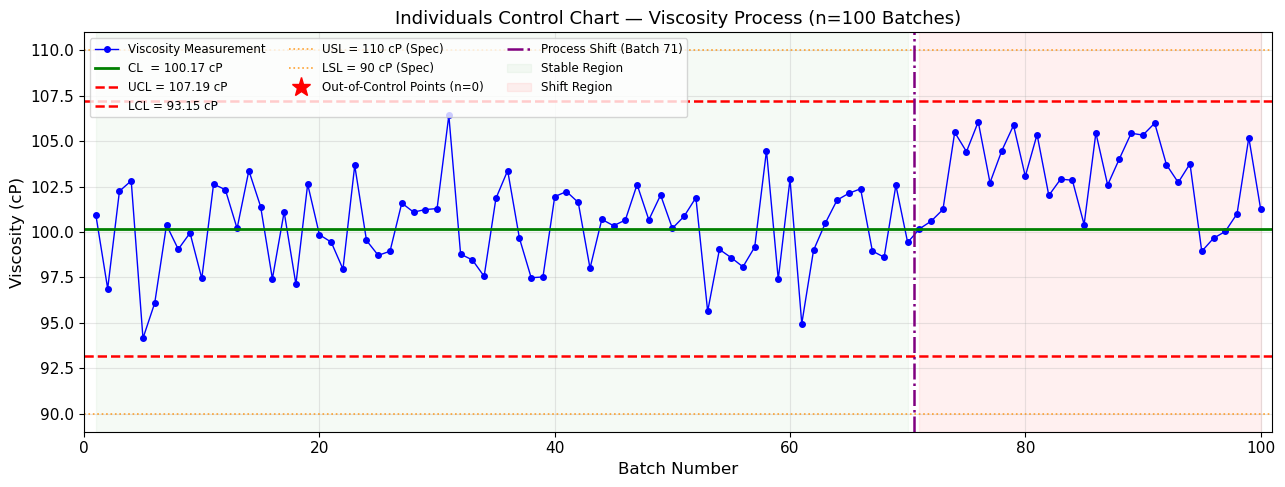

✓ 失控點數量: 0 個 (批次: [])


In [12]:
fig, ax = plt.subplots(figsize=(13, 5))

# 全部觀測值折線
ax.plot(batch_idx, viscosity, 'b-o', markersize=4,
        linewidth=1.0, label='Viscosity Measurement', zorder=2)

# 管制界限與中心線
ax.axhline(CL,  color='green', linestyle='-',  linewidth=2.0,
           label=f'CL  = {CL:.2f} cP')
ax.axhline(UCL, color='red',   linestyle='--', linewidth=1.8,
           label=f'UCL = {UCL:.2f} cP')
ax.axhline(LCL, color='red',   linestyle='--', linewidth=1.8,
           label=f'LCL = {LCL:.2f} cP')

# 規格界限（參考用）
ax.axhline(USL, color='darkorange', linestyle=':',  linewidth=1.2,
           alpha=0.8, label=f'USL = {USL:.0f} cP (Spec)')
ax.axhline(LSL, color='darkorange', linestyle=':',  linewidth=1.2,
           alpha=0.8, label=f'LSL = {LSL:.0f} cP (Spec)')

# 標示失控點（超出 UCL 或低於 LCL）
ooc_mask = (viscosity > UCL) | (viscosity < LCL)
n_ooc = ooc_mask.sum()
ax.plot(batch_idx[ooc_mask], viscosity[ooc_mask],
        'r*', markersize=14, zorder=3,
        label=f'Out-of-Control Points (n={n_ooc})')

# 製程偏移切割線
ax.axvline(N_STABLE + 0.5, color='purple', linestyle='-.', linewidth=1.8,
           label=f'Process Shift (Batch {N_STABLE+1})')

# 標示兩段區域
ax.axvspan(1, N_STABLE, alpha=0.04, color='green', label='Stable Region')
ax.axvspan(N_STABLE + 1, len(viscosity), alpha=0.06, color='red', label='Shift Region')

ax.set_xlabel('Batch Number')
ax.set_ylabel('Viscosity (cP)')
ax.set_title('Individuals Control Chart — Viscosity Process (n=100 Batches)')
ax.legend(loc='upper left', fontsize=8.5, ncol=3)
ax.set_xlim(0, len(viscosity) + 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'control_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 失控點數量: {n_ooc} 個 (批次: {batch_idx[ooc_mask].tolist()})")

---
### 8. 製程均值偏離目標之假設檢定

以 `scipy.stats.ttest_1samp()` 對三種情境進行單樣本 t 檢定：

- $H_0$ ：製程均值 $\mu = 100\ \text{cP}$ （目標值）
- $H_1$ ：製程均值 $\mu \neq 100\ \text{cP}$
- 顯著水準： $\alpha = 0.05$


In [9]:
ALPHA = 0.05   # 顯著水準

scenarios = [
    ('全體數據  (批次   1–100)', viscosity),
    ('穩定段    (批次   1–70 )', x_stable),
    ('偏移段    (批次  71–100)', x_shift),
]

print("=" * 65)
print("  單樣本 t 檢定：H₀: μ = 100 cP  vs  H₁: μ ≠ 100 cP")
print(f"  顯著水準 α = {ALPHA}")
print("=" * 65)

for label, data in scenarios:
    t_stat, p_val = stats.ttest_1samp(data, popmean=TARGET)
    mean_val = np.mean(data)
    # 95% 信賴區間
    ci_lo, ci_hi = stats.t.interval(0.95, df=len(data)-1,
                                    loc=mean_val,
                                    scale=stats.sem(data))
    reject = p_val < ALPHA
    symbol = "✗ 拒絕 H₀" if reject else "○ 無法拒絕 H₀"
    print(f"\n  情境: {label}")
    print(f"    樣本均值 x̄ = {mean_val:.4f} cP")
    print(f"    95% 信賴區間: [{ci_lo:.4f}, {ci_hi:.4f}] cP")
    print(f"    t 統計量    = {t_stat:+.4f}")
    print(f"    p 值        = {p_val:.6f}")
    print(f"    結論        : {symbol}  (均值{'顯著' if reject else '未顯著'}偏離目標值 100 cP)")

print("\n" + "=" * 65)

  單樣本 t 檢定：H₀: μ = 100 cP  vs  H₁: μ ≠ 100 cP
  顯著水準 α = 0.05

  情境: 全體數據  (批次   1–100)
    樣本均值 x̄ = 101.0492 cP
    95% 信賴區間: [100.5243, 101.5741] cP
    t 統計量    = +3.9661
    p 值        = 0.000138
    結論        : ✗ 拒絕 H₀  (均值顯著偏離目標值 100 cP)

  情境: 穩定段    (批次   1–70 )
    樣本均值 x̄ = 100.1718 cP
    95% 信賴區間: [99.6137, 100.7299] cP
    t 統計量    = +0.6141
    p 值        = 0.541179
    結論        : ○ 無法拒絕 H₀  (均值未顯著偏離目標值 100 cP)

  情境: 偏移段    (批次  71–100)
    樣本均值 x̄ = 103.0965 cP
    95% 信賴區間: [102.2903, 103.9026] cP
    t 統計量    = +7.8553
    p 值        = 0.000000
    結論        : ✗ 拒絕 H₀  (均值顯著偏離目標值 100 cP)



---
### 9. 製程能力圖繪製

製程能力圖（Capability Plot）整合：直方圖（數據分布）＋ 常態 PDF 曲線 ＋ 規格界限（LSL / USL），並標注 $C_p$ 、 $C_{pk}$ 、良率與 ppm，便於快速視覺化判讀製程狀態。


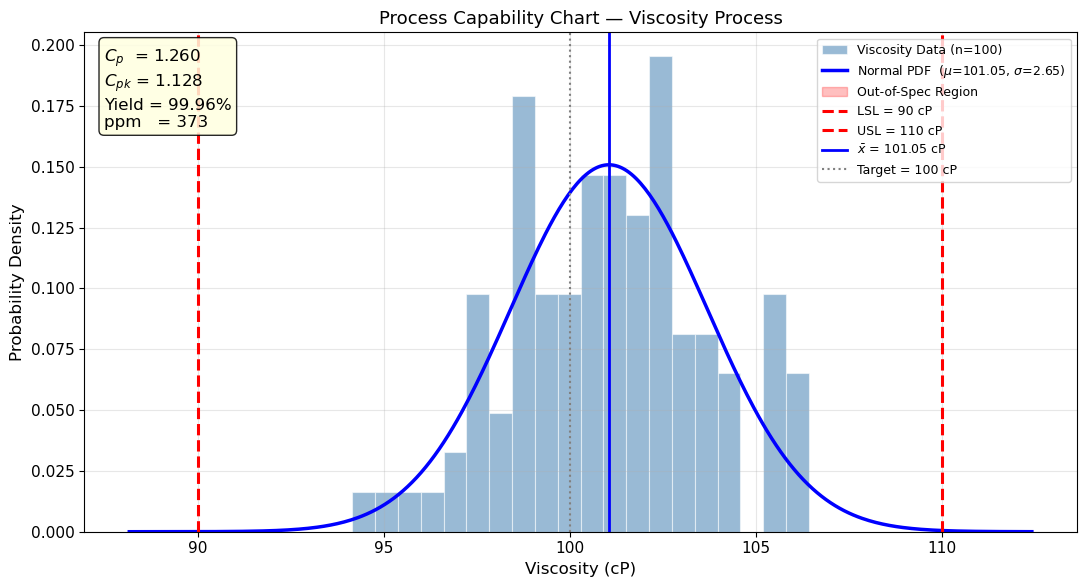

✓ 製程能力圖已儲存


In [13]:
x_plot    = np.linspace(viscosity.min() - 6, viscosity.max() + 6, 400)
pdf_curve = stats.norm.pdf(x_plot, loc=x_bar, scale=s)

fig, ax = plt.subplots(figsize=(11, 6))

# 直方圖（密度正規化）
ax.hist(viscosity, bins=20, density=True, color='steelblue',
        alpha=0.55, edgecolor='white', linewidth=0.8,
        label='Viscosity Data (n=100)')

# 常態 PDF 曲線
ax.plot(x_plot, pdf_curve, 'b-', linewidth=2.5,
        label=f'Normal PDF  ($\\mu$={x_bar:.2f}, $\\sigma$={s:.2f})')

# 填色：規格外區域
ax.fill_between(x_plot, pdf_curve,
                where=(x_plot < LSL), color='red', alpha=0.25,
                label='Out-of-Spec Region')
ax.fill_between(x_plot, pdf_curve,
                where=(x_plot > USL), color='red', alpha=0.25)

# 規格界限垂直線
ax.axvline(LSL, color='red',   linestyle='--', linewidth=2.2,
           label=f'LSL = {LSL:.0f} cP')
ax.axvline(USL, color='red',   linestyle='--', linewidth=2.2,
           label=f'USL = {USL:.0f} cP')

# 製程均值與目標值
ax.axvline(x_bar,  color='blue',   linestyle='-',  linewidth=2.0,
           label=f'$\\bar{{x}}$ = {x_bar:.2f} cP')
ax.axvline(TARGET, color='gray',   linestyle=':',  linewidth=1.5,
           label=f'Target = {TARGET:.0f} cP')

# 標注能力指標文字框
textstr = '\n'.join([
    f'$C_p$  = {Cp:.3f}',
    f'$C_{{pk}}$ = {Cpk:.3f}',
    f'Yield = {yield_pct:.2f}%',
    f'ppm   = {defect_ppm:.0f}',
])
props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
ax.text(0.02, 0.97, textstr, transform=ax.transAxes,
        fontsize=12, verticalalignment='top', bbox=props)

ax.set_xlabel('Viscosity (cP)')
ax.set_ylabel('Probability Density')
ax.set_title('Process Capability Chart — Viscosity Process')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'capability_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 製程能力圖已儲存")

---
### 10. 綜合結論

| 分析項目 | 實際結果 | 判斷 |
|---------|----------|------|
| $C_p$ | 1.260 | 精密度勉強合格（建議目標 ≥ 1.33） |
| $C_{pk}$ | 1.128 < $C_p$ | 均值偏移導致 $C_{pk}$ 下降，需對中 |
| 良率 | 99.96%（373 ppm） | 良率高但均值偏移使 USL 側不良率偏高 |
| 管制圖 | ±3σ 規則：0 個失控點 | 偏移量（+3 cP）小於 3σ 界限寬（±7 cP），個別點未超出；但批次 71 起呈現明顯正向游程，憑 WECO 連串規則可偵測 |
| t 檢定（全體） | p = 0.000138 < 0.05 | 整體均值顯著偏離目標值 100 cP |
| t 檢定（穩定段） | p = 0.541 > 0.05 | 穩定段：製程受控 ✓ |
| t 檢定（偏移段） | p ≈ 0.000 | 偏移段：均值極顯著偏離目標值 100 cP |

> **說明**：個別觀測值管制圖的 ±3σ 規則對均值偏移量較小的情形靈敏度有限。實務上應搭配 **WECO 連串規則**（如連續 8 點在中心線同側），才能及早偵測製程偏移。

**改善建議：**
1. 調查第 71 批起原料或操作條件的異常，消除均值偏移根本原因
2. 製程均值對中後， $C_{pk}$ 將接近 $C_p$ 水準（目標： $C_{pk} > 1.33$ ）
3. 若 $C_p < 1.33$ ，進一步降低製程變異（優化配方 / 操作條件）
4. 部署即時管制圖系統，搭配 WECO 連串規則設定自動警報機制

**`scipy.stats` 關鍵函式回顧：**

| 函式 | 本例用途 |
|------|---------|
| `scipy.stats.describe()` | 描述統計摘要 |
| `scipy.stats.norm.cdf()` | 計算良率與不良率 (ppm) |
| `scipy.stats.norm.pdf()` | 繪製常態 PDF 曲線 |
| `scipy.stats.norm.interval(0.9973)` | 計算 ±3σ 管制界限 (UCL/LCL) |
| `scipy.stats.ttest_1samp()` | 單樣本 t 檢定：均值偏離目標值 |
